In [1]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\naman yadav\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

path = kagglehub.dataset_download("spypsc07/amazon-products")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\spypsc07\amazon-products\versions\1


In [3]:
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print(csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df.shape

['amazon_product.csv']


(64, 22)

In [4]:
df.describe()

,Unnamed: 0,product_star_rating,product_num_ratings,product_num_offers,unit_count
count,64.000000,54.000000,6.400000e+01,64.000000,5.000000
mean,31.500000,4.244444,5.210164e+04,4.859375,15.200000
std,18.618987,0.558187,1.576855e+05,8.145243,25.390943
min,0.000000,1.800000,0.000000e+00,1.000000,0.000000
25%,15.750000,4.100000,4.775000e+01,1.000000,2.000000
50%,31.500000,4.400000,9.675000e+02,1.000000,3.000000
75%,47.250000,4.600000,1.384625e+04,4.000000,11.000000
max,63.000000,4.800000,1.015448e+06,34.000000,60.000000


In [5]:
df.dtypes

Unnamed: 0                       int64
asin                               str
product_title                      str
product_price                      str
product_original_price             str
currency                           str
product_star_rating            float64
product_num_ratings              int64
product_url                        str
product_photo                      str
product_num_offers               int64
product_minimum_offer_price        str
is_best_seller                    bool
is_amazon_choice                  bool
is_prime                          bool
climate_pledge_friendly           bool
sales_volume                       str
delivery                           str
has_variations                    bool
product_availability               str
unit_price                         str
unit_count                     float64
dtype: object

In [6]:
df.sample(5)

,Unnamed: 0,asin,product_title,product_price,product_original_price,currency,product_star_rating,product_num_ratings,product_url,product_photo,...,is_best_seller,is_amazon_choice,is_prime,climate_pledge_friendly,sales_volume,delivery,has_variations,product_availability,unit_price,unit_count
35,35,B0D4DJ6BRR,DAYBETTER LED Strip Lights 130ft (2 Rolls of 6...,$12.99,NaN,USD,4.5,27686,https://www.amazon.com/dp/B0D4DJ6BRR,https://m.media-amazon.com/images/I/813vxzjiCh...,...,False,False,True,False,10K+ bought in past month,"FREE delivery Tue, Aug 6 on $35 of items shipp...",False,NaN,NaN,NaN
30,30,B0D94H3739,Going Balls: 3D Race,$0.00,NaN,USD,4.7,8,https://www.amazon.com/dp/B0D94H3739,https://m.media-amazon.com/images/I/811avYAfLl...,...,False,False,False,False,"Jul 10, 2024",Available instantly on compatible devices,False,NaN,NaN,NaN
28,28,B0DBM9KD5M,Christmas (Amazon Exclusive Blue &amp;amp; Whi...,$27.98,NaN,USD,NaN,0,https://www.amazon.com/dp/B0DBM9KD5M,https://m.media-amazon.com/images/I/71kmhd1Otd...,...,False,False,True,False,NaN,"FREE delivery Tue, Oct 15 on $35 of items ship...",False,NaN,NaN,NaN
45,45,B01GGU0XWC,It Ends with Us,$0.00,$20.24,USD,4.7,333273,https://www.amazon.com/dp/B01GGU0XWC,https://m.media-amazon.com/images/I/815GWEqlkO...,...,True,False,False,False,Other formats:,Available instantly,False,NaN,NaN,NaN
10,10,B09SM24S8C,"Samsung Galaxy A03s Cell Phone, AT&amp;T GSM U...",$70.61,$87.14,USD,3.9,462,https://www.amazon.com/dp/B09SM24S8C,https://m.media-amazon.com/images/I/51m45B3Yy+...,...,False,False,True,False,2K+ bought in past month,"FREE delivery Wed, Aug 7",True,NaN,NaN,NaN


In [7]:

df.columns

Index(['Unnamed: 0', 'asin', 'product_title', 'product_price',
       'product_original_price', 'currency', 'product_star_rating',
       'product_num_ratings', 'product_url', 'product_photo',
       'product_num_offers', 'product_minimum_offer_price', 'is_best_seller',
       'is_amazon_choice', 'is_prime', 'climate_pledge_friendly',
       'sales_volume', 'delivery', 'has_variations', 'product_availability',
       'unit_price', 'unit_count'],
      dtype='str')

In [8]:

df.drop(columns=['Unnamed: 0','product_availability','unit_price','unit_count'], errors='ignore', inplace=True)


In [9]:
df.isnull().sum()

asin                            0
product_title                   0
product_price                   0
product_original_price         37
currency                        0
product_star_rating            10
product_num_ratings             0
product_url                     0
product_photo                   0
product_num_offers              0
product_minimum_offer_price     0
is_best_seller                  0
is_amazon_choice                0
is_prime                        0
climate_pledge_friendly         0
sales_volume                    3
delivery                        1
has_variations                  0
dtype: int64

In [10]:
df = df.fillna('Nan')

In [11]:
df.dtypes

asin                              str
product_title                     str
product_price                     str
product_original_price            str
currency                          str
product_star_rating            object
product_num_ratings             int64
product_url                       str
product_photo                     str
product_num_offers              int64
product_minimum_offer_price       str
is_best_seller                   bool
is_amazon_choice                 bool
is_prime                         bool
climate_pledge_friendly          bool
sales_volume                      str
delivery                          str
has_variations                   bool
dtype: object

In [12]:
df['sales_volume'].value_counts()

sales_volume
10K+ bought in past month     6
Other formats:                6
3K+ bought in past month      5
2K+ bought in past month      5
List:                         4
500+ bought in past month     3
Nan                           3
1K+ bought in past month      2
40K+ bought in past month     2
Other format:                 2
50+ bought in past month      2
6K+ bought in past month      1
5K+ bought in past month      1
200+ bought in past month     1
30K+ bought in past month     1
Jun 24, 2021                  1
700+ bought in past month     1
100K+ bought in past month    1
Jul 10, 2024                  1
Digital List Price:           1
Jun 26, 2024                  1
60K+ bought in past month     1
Jul 19, 2024                  1
May 30, 2024                  1
Jul 16, 2015                  1
Mar 20, 2024                  1
900+ bought in past month     1
2023                          1
Oct 11, 2019                  1
Oct 27, 2011                  1
Jul 8, 2015                

In [13]:
(df['delivery'] == 'Available instantly').sum()


np.int64(7)

In [32]:
df.columns.to_list()

['product_id',
 'title',
 'product_price',
 'selling_price',
 'currency',
 'star_rating',
 'ratings',
 'product_url',
 'product_photo',
 'offer_in_numbers',
 'product_minimum_offer_price',
 'best_seller',
 'amazon_choice',
 'prime',
 'climate_pledge_friendly',
 'sales_volume',
 'delivery',
 'has_variations']

In [15]:
df.rename(columns={
    'is_best_seller': 'best_seller',
    'is_amazon_choice': 'amazon_choice',
    'is_prime': 'prime',
    'product_title': 'title',
    'product_price' : 'product_price',
    'product_original_price': 'selling_price',
    'product_star_rating' : 'star_rating',
    'product_num_ratings' : 'ratings',
    'product_num_offers':'offer_in_numbers',
    'asin' : 'product_id'
    
}, inplace=True)

In [26]:
# Melt the two price columns into one "long" format
df_melt = df.melt(
    id_vars=['currency', 'title'],
    value_vars=['product_price', 'selling_price'],
    var_name='Price_Type',
    value_name='Price'
)


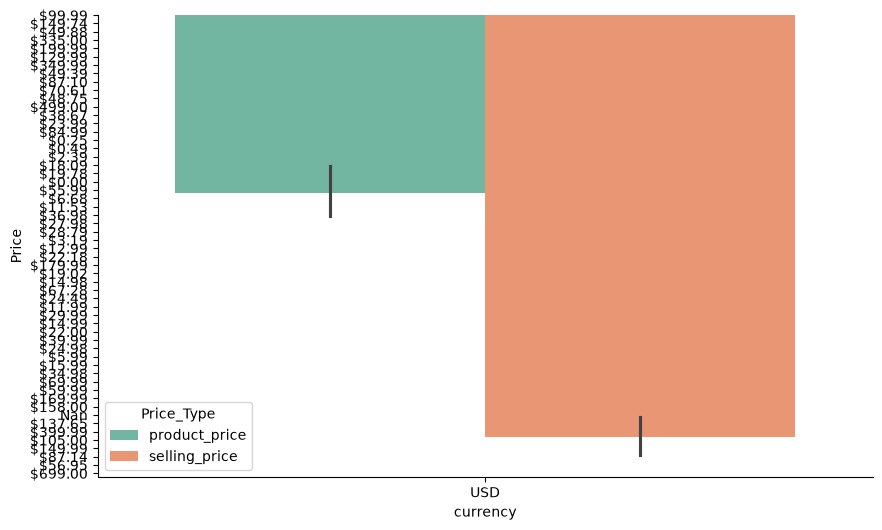

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_melt,
    x='currency',
    y='Price',
    hue='Price_Type',
    palette='Set2'
)
sns.despine()
plt.show()


<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:2: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\3973662853.py:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['product_price'] = pd.to_numeric(df['product_price'].replace('[\$,]', '', regex=True), errors='coerce')
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\397

<Axes: xlabel='discount', ylabel='Count'>

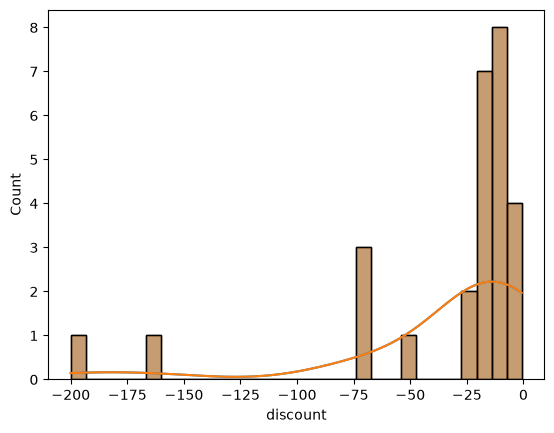

In [34]:
df['product_price'] = pd.to_numeric(df['product_price'].replace('[\$,]', '', regex=True), errors='coerce')
df['selling_price'] = pd.to_numeric(df['selling_price'].replace('[\$,]', '', regex=True), errors='coerce')
df['offer_in_numbers'] = df['product_price'] - df['selling_price']
df['discount'] = df['offer_in_numbers']

sns.histplot(df['discount'].dropna(), bins=30, kde=True)
sns.histplot(df['discount'], bins=30, kde=True)


<Axes: >

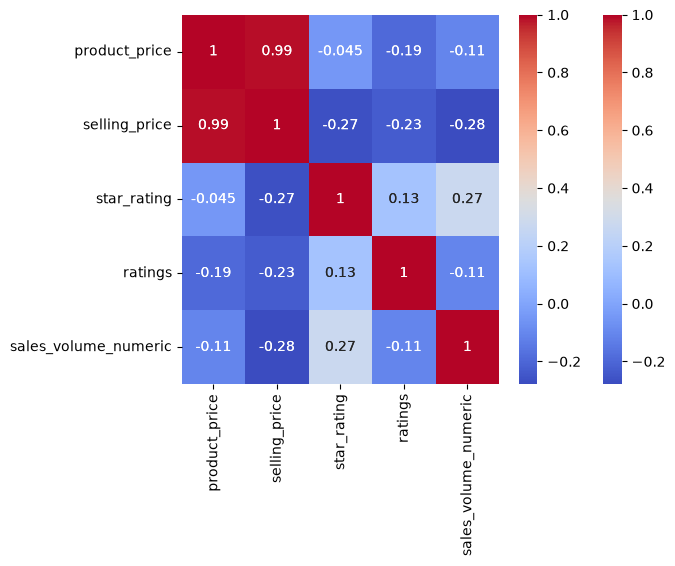

In [36]:
import re

def parse_sales_volume(x):
    if pd.isna(x):
        return np.nan
    text = str(x).strip()
    if text.lower() == 'nan':
        return np.nan
    m = re.search(r'([\d\.]+)\s*([KMkm]?)', text)
    if not m:
        return np.nan
    value = float(m.group(1))
    suffix = m.group(2).upper()
    if suffix == 'K':
        value *= 1000
    elif suffix == 'M':
        value *= 1000000
    return value

df['sales_volume_numeric'] = df['sales_volume'].apply(parse_sales_volume)

corr = df[['product_price', 'selling_price', 'star_rating', 'ratings', 'sales_volume_numeric']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
sns.heatmap(corr, annot=True, cmap='coolwarm')


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\1468447266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='star_rating', data=df, palette='muted')


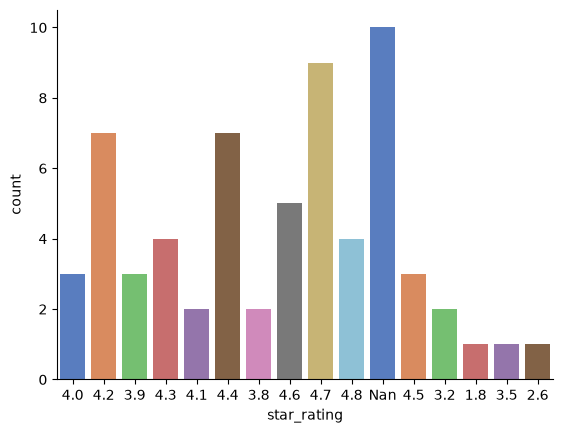

In [37]:
plt.Figure(figsize=(8,6))
sns.countplot(x='star_rating', data=df, palette='muted')
sns.despine()
plt.show()

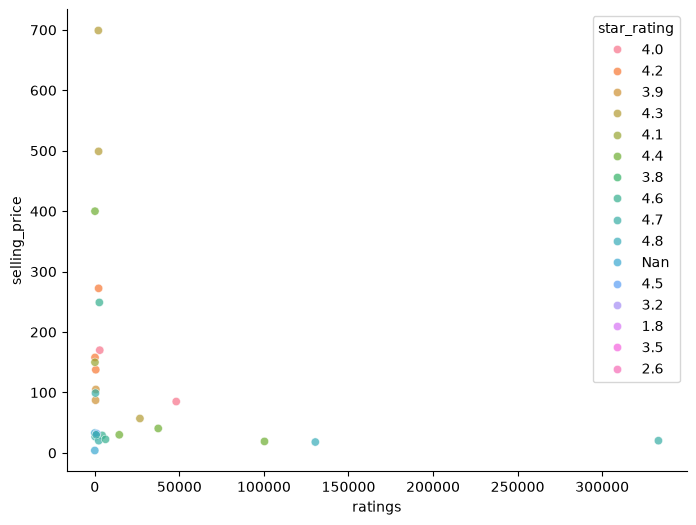

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='ratings', y='selling_price', data=df, hue='star_rating', alpha=0.7)
sns.despine()
plt.show()


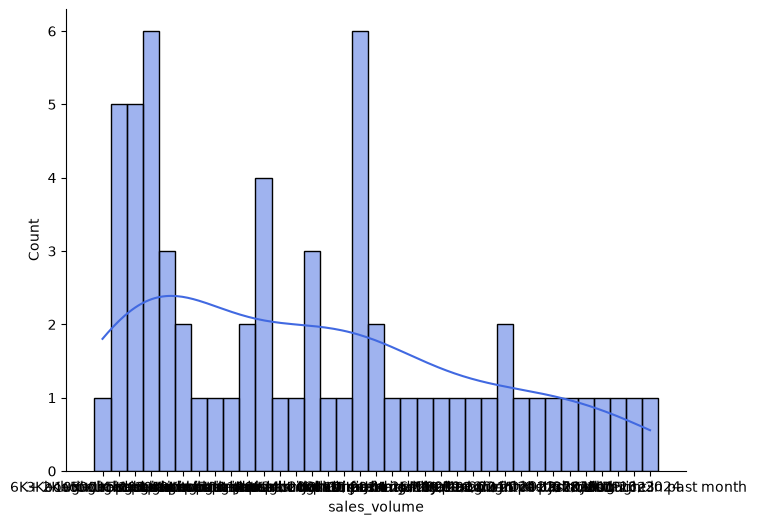

In [39]:
plt.figure(figsize=(8,6))
sns.histplot(df['sales_volume'], bins=30, kde=True, color='royalblue')
sns.despine()
plt.show()


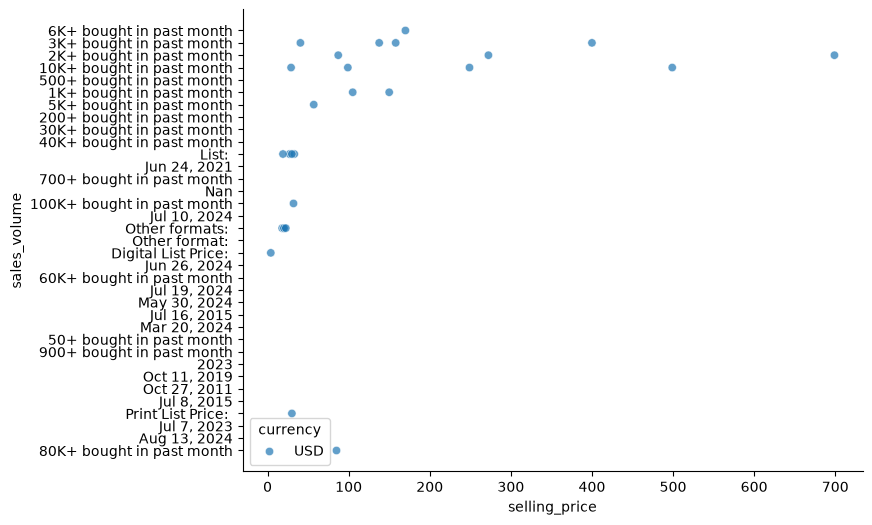

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='selling_price', y='sales_volume', data=df, hue='currency', alpha=0.7)
sns.despine()
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\1226580718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='prime', y='sales_volume', data=df, palette='muted')


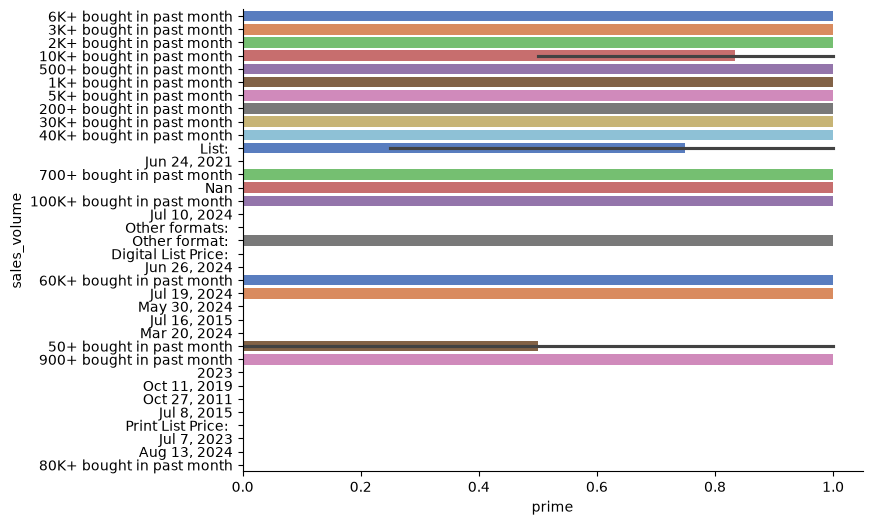

In [41]:
plt.figure(figsize=(8,6))
sns.barplot(x='prime', y='sales_volume', data=df, palette='muted')
sns.despine()
plt.show()


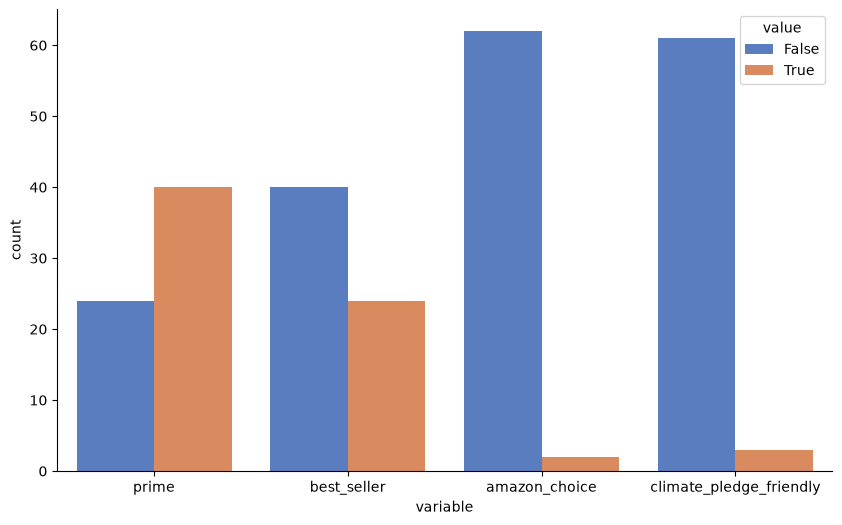

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(data=df[['prime','best_seller','amazon_choice','climate_pledge_friendly']].melt(),
              x='variable', hue='value', palette='muted')
sns.despine()
plt.show()


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\2476402350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prime', y='selling_price', data=df, palette='Set2')


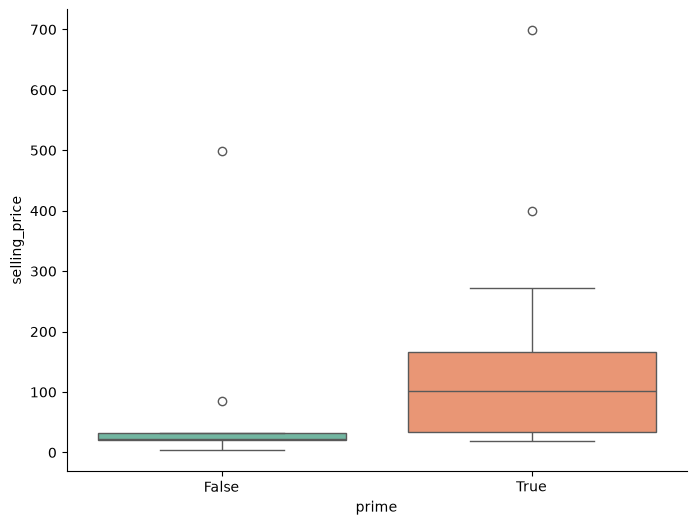

In [43]:
plt.figure(figsize=(8,6))
sns.boxplot(x='prime', y='selling_price', data=df, palette='Set2')
sns.despine()
plt.show()


<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\naman yadav\AppData\Local\Temp\ipykernel_25560\48009597.py:6: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['product_minimum_offer_price'].replace('[\$,]', '', regex=True),


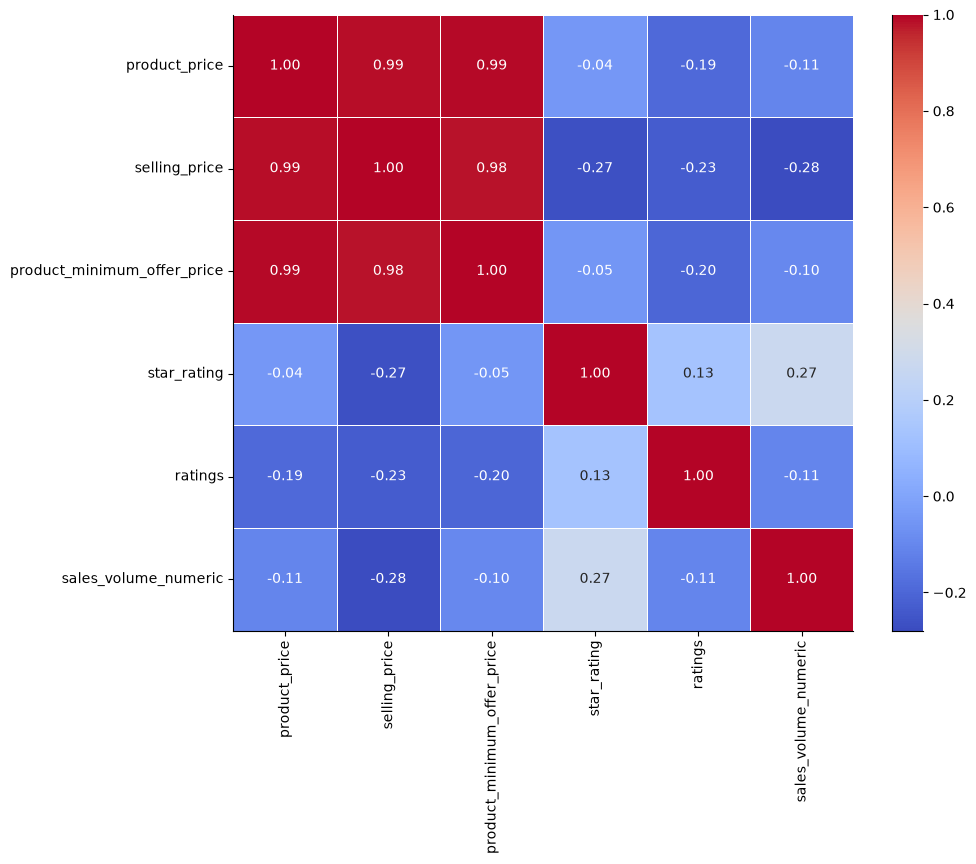

In [45]:
plt.figure(figsize=(10,8))
numeric_cols = ['product_price','selling_price','product_minimum_offer_price',
                'star_rating','ratings','sales_volume']

df['product_minimum_offer_price'] = pd.to_numeric(
    df['product_minimum_offer_price'].replace('[\$,]', '', regex=True),
    errors='coerce'
)
numeric_cols = [
    'product_price',
    'selling_price',
    'product_minimum_offer_price',
    'star_rating',
    'ratings',
    'sales_volume_numeric'
]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
sns.despine()
plt.show()
